In [22]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

SEED = 42
np.random.seed(SEED)

df = pd.read_csv("../user_movie_rates.csv")
df.head()

,user_id,movie_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40+00:00
1,1,661,3,2000-12-31 22:35:09+00:00
2,1,914,3,2000-12-31 22:32:48+00:00
3,1,3408,4,2000-12-31 22:04:35+00:00
4,1,2355,5,2001-01-06 23:38:11+00:00


In [23]:
len(df)

948367

Превращаем таблицу рейтингов в граф взаимодействий

Формируем семантику “позитивного сигнала”. Однако, у разных пользователей шкала оценки субъективна и выбор порога для позитивного сигнала не очевидна. Пользователь, которому понравился фильм, вполне может оценить его на 3, сравнивая его относительно других фильмов, которые ему понравились больше. Также, считаем как данность тот факт, что пользователь не поставит самую низкую оценку фильму, который ему понравился.

Тогда выдвигаем ряд гипотез, по которым пороговое значение может быть одно из следующих [3.0, 4.0, 5.0]

Формируем минимальный объём пользовательского сигнала, необходимый для построения устойчивого профиля пользователя.

При малом числе позитивных взаимодействий (например, 4–5 фильмов) структура его связей в графе может быть недостаточно информативной, что затрудняет обучение качественного эмбеддинга.
Предполагаем, что увеличение числа исторических позитивных взаимодействий пользователя позволит DeepWalk точнее встроить его в графовую структуру и повысить качество рекомендаций.

Тогда выдвигаем гипотезу о влиянии минимального числа позитивных оценок пользователя на итоговые метрики качества и рассматриваем значения min_pos ∈ [5, 10, 20].

In [24]:
from typing import Dict, List, Tuple, Optional, Set
from common.data_prep import build_edges, filter_users_min_pos

THRESHOLDS = [3.0, 4.0, 5.0]
MIN_POS_LIST = [5, 10, 20]

experiments: Dict[str, pd.DataFrame] = {}

for t in THRESHOLDS:
    df_pos_thr = build_edges(df, threshold=t)

    for mp in MIN_POS_LIST:
        df_pos = filter_users_min_pos(df_pos_thr, min_pos=mp)

        name = f"thr_{t:.1f}_minpos_{mp}"
        experiments[name] = df_pos

        print(
            f"{name:20s} | "
            f"edges={len(df_pos):8d} | "
            f"users={df_pos['user_id'].nunique():6d} | "
            f"movies={df_pos['movie_id'].nunique():6d}"
        )

thr_3.0_minpos_5     | edges=  794223 | users=  6038 | movies=  3264
thr_3.0_minpos_10    | edges=  794183 | users=  6033 | movies=  3264
thr_3.0_minpos_20    | edges=  788215 | users=  5673 | movies=  3261
thr_4.0_minpos_5     | edges=  545628 | users=  6033 | movies=  3197
thr_4.0_minpos_10    | edges=  544897 | users=  5937 | movies=  3196
thr_4.0_minpos_20    | edges=  531904 | users=  5083 | movies=  3189
thr_5.0_minpos_5     | edges=  212898 | users=  5614 | movies=  2944
thr_5.0_minpos_10    | edges=  206814 | users=  4746 | movies=  2940
thr_5.0_minpos_20    | edges=  186161 | users=  3282 | movies=  2920


In [25]:
from common.data_prep import interactions_stats

for name, df_pos in experiments.items():
    s = interactions_stats(df_pos)
    print(f"\n{name}")
    print(s)


thr_3.0_minpos_5
users_total    6038.0
min               6.0
p25              36.0
median           77.0
p75             168.0
max            1827.0
users_lt5         0.0
users_lt10        5.0
users_lt20      365.0
dtype: float64

thr_3.0_minpos_10
users_total    6033.0
min              10.0
p25              36.0
median           77.0
p75             168.0
max            1827.0
users_lt5         0.0
users_lt10        0.0
users_lt20      360.0
dtype: float64

thr_3.0_minpos_20
users_total    5673.0
min              20.0
p25              41.0
median           85.0
p75             178.0
max            1827.0
users_lt5         0.0
users_lt10        0.0
users_lt20        0.0
dtype: float64

thr_4.0_minpos_5
users_total    6033.0
min               5.0
p25              26.0
median           55.0
p75             117.0
max            1334.0
users_lt5         0.0
users_lt10       96.0
users_lt20      950.0
dtype: float64

thr_4.0_minpos_10
users_total    5937.0
min              10.0
p25        

Разделяем данные на обучающую и тестовую выборки на основе временной информации. Поскольку задача рекомендательной системы — предсказывать будущие взаимодействия пользователя, некорректно формировать train/test случайным образом, так как это приводит к утечке информации из будущего в прошлое.

Для каждого пользователя сортируем позитивные взаимодействия по времени и отправляем последние last_n оценок в тестовую выборку, а остальные — в обучающую. Таким образом, модель обучается на исторических данных и оценивается на попытке предсказать следующие фильмы пользователя.

Выдвигаем гипотезу, что увеличение last_n (например, 1 → 2) может повысить стабильность метрик, так как вероятность попадания хотя бы одного релевантного фильма в топ-K возрастает.

In [26]:
from common.split import time_split_last_n

splits = {}
for name, df_pos in experiments.items():
    tr1, te1 = time_split_last_n(df_pos, last_n=1)
    tr2, te2 = time_split_last_n(df_pos, last_n=2)

    splits[(name, 1)] = (tr1, te1)
    splits[(name, 2)] = (tr2, te2)

    print(f"{name:6s} | last1: train={len(tr1):7d} test={len(te1):6d} | last2: train={len(tr2):7d} test={len(te2):6d}")

thr_3.0_minpos_5 | last1: train= 788185 test=  6038 | last2: train= 782147 test= 12076
thr_3.0_minpos_10 | last1: train= 788150 test=  6033 | last2: train= 782117 test= 12066
thr_3.0_minpos_20 | last1: train= 782542 test=  5673 | last2: train= 776869 test= 11346
thr_4.0_minpos_5 | last1: train= 539595 test=  6033 | last2: train= 533562 test= 12066
thr_4.0_minpos_10 | last1: train= 538960 test=  5937 | last2: train= 533023 test= 11874
thr_4.0_minpos_20 | last1: train= 526821 test=  5083 | last2: train= 521738 test= 10166
thr_5.0_minpos_5 | last1: train= 207284 test=  5614 | last2: train= 201670 test= 11228
thr_5.0_minpos_10 | last1: train= 202068 test=  4746 | last2: train= 197322 test=  9492
thr_5.0_minpos_20 | last1: train= 182879 test=  3282 | last2: train= 179597 test=  6564


In [27]:
!pip install networkx


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Преобразуем таблицу взаимодействий в двудольный граф пользователь–фильм. Вершинами графа выступают пользователи и фильмы, а рёбрами — позитивные взаимодействия между ними.

In [28]:
import networkx as nx

def build_bipartite_graph(train_edges, user_col="user_id", item_col="movie_id"):
    G = nx.Graph()
    for u, i in train_edges[[user_col, item_col]].itertuples(index=False):
        G.add_edge(f"u_{int(u)}", f"i_{int(i)}")
    return G

Генерируем последовательности случайных блужданий по графу. Для каждой вершины выполняется несколько случайных проходов длиной walk_length, в ходе которых на каждом шаге выбирается один из соседних узлов.

In [29]:
def generate_random_walks(G, walk_length=20, walks_per_node=10, seed=42):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    walks = []

    for _ in range(walks_per_node):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            cur = start
            for _ in range(walk_length - 1):
                neigh = list(G.neighbors(cur))
                if not neigh:
                    break
                cur = neigh[rng.integers(0, len(neigh))]
                walk.append(cur)
            walks.append(walk)
    return walks

In [30]:
!pip install gensim


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
from gensim.models import Word2Vec

def train_deepwalk(walks, dim=128, window=5, epochs=5, workers=4, seed=42, negative=5):
    model = Word2Vec(
        sentences=walks,
        vector_size=dim,
        window=window,
        min_count=0,
        sg=1,          # skip-gram
        hs=0,
        negative=negative,
        workers=workers,
        seed=seed,
        epochs=epochs
    )
    return model

Реализуем метрики качества ранжирования рекомендаций. Поскольку модель возвращает упорядоченный список фильмов, важно учитывать не только факт попадания релевантного элемента в топ-K, но и его позицию в этом списке.

- Average Precision@K (AP@K) учитывает, насколько рано появляются релевантные фильмы и усредняет точность по всем позициям, где произошли попадания.

- NDCG@K (Normalized Discounted Cumulative Gain) дополнительно снижает вклад релевантных элементов, расположенных ниже в списке, логарифмически штрафуя поздние позиции. Метрика нормируется на идеальный порядок.

- MRR@K (Mean Reciprocal Rank) измеряет, насколько рано появляется первый релевантный фильм: чем выше он в списке, тем больше значение метрики.

In [32]:
def _ap_at_k(ranked, gt, k):
    hits = 0
    s = 0.0
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            hits += 1
            s += hits / idx
    return 0.0 if hits == 0 else s / min(len(gt), k)

def _ndcg_at_k(ranked, gt, k):
    dcg = 0.0
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            dcg += 1.0 / np.log2(idx + 1)
    ideal_len = min(len(gt), k)
    if ideal_len == 0:
        return 0.0
    ideal = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_len + 1))
    return dcg / ideal

def _mrr_at_k(ranked, gt, k):
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            return 1.0 / idx
    return 0.0

In [33]:
def evaluate_ranking(
    model,
    train_edges,
    test_edges,
    user_col="user_id",
    item_col="movie_id",
    k_list=(5,10,20),
    sample_negatives=500,
    seed=42
):
    rng = np.random.default_rng(seed)

    # Users/items from train
    users_all = sorted(train_edges[user_col].unique().astype(int).tolist())
    items_all = sorted(train_edges[item_col].unique().astype(int).tolist())

    # оставляем только то, что реально есть в Word2Vec
    users = [u for u in users_all if f"u_{u}" in model.wv]
    items = [i for i in items_all if f"i_{i}" in model.wv]

    item_set = set(items)
    item_index = {it: idx for idx, it in enumerate(items)}

    # Формируем “правду” (GT) и историю просмотров
    gt_raw = test_edges.groupby(user_col)[item_col].apply(lambda s: set(map(int, s.tolist()))).to_dict()
    seen_raw = train_edges.groupby(user_col)[item_col].apply(lambda s: set(map(int, s.tolist()))).to_dict() # не рекомендовать то, что уже было в обучении

    # Собираем матрицы эмбеддингов
    U = np.vstack([model.wv[f"u_{u}"] for u in users])
    I = np.vstack([model.wv[f"i_{i}"] for i in items])

    # косинусная близость
    U /= np.maximum(np.linalg.norm(U, axis=1, keepdims=True), 1e-12)
    I /= np.maximum(np.linalg.norm(I, axis=1, keepdims=True), 1e-12)

    rows = []
    for ui, u in enumerate(users):

        # Пропускаем пользователей, для которых нет тестовых фильмов
        if u not in gt_raw:
            continue

        # Оставляем в ground truth только те фильмы, для которых у нас есть эмбеддинги
        gt_u = set(it for it in gt_raw[u] if it in item_set)
        if not gt_u:
            continue

        seen_u = set(it for it in seen_raw.get(u, set()) if it in item_set)

        # Кандидаты-негативы: фильмы, которые пользователь не видел в train и которые не являются истинными тестовыми
        neg_pool = list((item_set - seen_u) - gt_u)

        # Ранжируем все фильмы, кроме seen
        if sample_negatives is None:
            candidates = list(item_set - seen_u)
        else:
            if len(neg_pool) > sample_negatives:
                neg = rng.choice(neg_pool, size=sample_negatives, replace=False).tolist()
            else:
                neg = neg_pool
            candidates = list(gt_u) + neg

        # Скоринг и получение ранжированного списка
        cand_idx = np.fromiter((item_index[it] for it in candidates), dtype=int)
        scores = I[cand_idx] @ U[ui]
        ranked = [candidates[j] for j in np.argsort(-scores)]

        # Метрики на каждом K и усреднение
        for k in k_list:
            topk = ranked[:k]
            hits = sum(1 for x in topk if x in gt_u)
            rows.append({
                "k": k,
                "precision": hits / k,
                "recall": hits / len(gt_u),
                "map": _ap_at_k(ranked, gt_u, k),
                "ndcg": _ndcg_at_k(ranked, gt_u, k),
                "mrr": _mrr_at_k(ranked, gt_u, k),
                "hitrate": 1.0 if hits > 0 else 0.0,
            })

    out = pd.DataFrame(rows).groupby("k").mean(numeric_only=True).reset_index()
    return out

In [34]:
def run_all_experiments(
    splits,
    experiments_order=None,
    last_list=(1,2),
    seed=42,
    # DeepWalk params:
    walk_length=20,
    walks_per_node=8,
    dim=128,
    window=5,
    epochs=5,
    workers=4,
    # Eval params:
    k_list=(5,10,20),
    sample_negatives=500
):
    all_rows = []

    if experiments_order is None:
        exp_names = sorted({k[0] for k in splits.keys()})
        def sort_key(name: str):
            parts = name.split("_")
            thr = float(parts[1])
            mp = int(parts[3])
            return (thr, mp)
        experiments_order = sorted(exp_names, key=sort_key)

    for name in experiments_order:
        for last_n in last_list:
            train_df, test_df = splits[(name, last_n)]

            G = build_bipartite_graph(train_df)
            walks = generate_random_walks(G, walk_length=walk_length, walks_per_node=walks_per_node, seed=seed)
            dw = train_deepwalk(walks, dim=dim, window=window, epochs=epochs, workers=workers, seed=seed)

            summary = evaluate_ranking(
                dw,
                train_df,
                test_df,
                k_list=k_list,
                sample_negatives=sample_negatives,
                seed=seed
            )

            parts = name.split("_")  # ["thr","3.0","minpos","10"]
            thr_val = float(parts[1])
            min_pos_val = int(parts[3])

            summary.insert(0, "last_n", last_n)
            summary.insert(0, "min_pos", min_pos_val)
            summary.insert(0, "threshold", thr_val)

            summary["experiment"] = name
            summary["train_edges"] = len(train_df)
            summary["test_edges"] = len(test_df)
            summary["graph_nodes"] = G.number_of_nodes()
            summary["graph_edges"] = G.number_of_edges()

            all_rows.append(summary)

            print(f"Done: {name} last{last_n} | nodes={G.number_of_nodes()} edges={G.number_of_edges()} walks={len(walks)}")

    return pd.concat(all_rows, ignore_index=True)

results_df = run_all_experiments(
    splits,
    experiments_order=None,
    last_list=(1,2),
    seed=42,
    walk_length=20,
    walks_per_node=8,
    dim=128,
    window=5,
    epochs=5,
    workers=4,
    k_list=(5,10,20),
    sample_negatives=500
)

results_df

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done: thr_3.0_minpos_5 last1 | nodes=9299 edges=788185 walks=74392


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done: thr_3.0_minpos_5 last2 | nodes=9297 edges=782147 walks=74376


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done: thr_5.0_minpos_20 last1 | nodes=6187 edges=182879 walks=49496


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done: thr_5.0_minpos_20 last2 | nodes=6180 edges=179597 walks=49440


,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,hitrate,experiment,train_edges,test_edges,graph_nodes,graph_edges
0,3.0,5,1,5,0.003811,0.019056,0.009293,0.011701,0.009293,0.019056,thr_3.0_minpos_5,788185,6038,9299,788185
1,3.0,5,1,10,0.003397,0.033969,0.011207,0.016447,0.011207,0.033969,thr_3.0_minpos_5,788185,6038,9299,788185
2,3.0,5,1,20,0.003148,0.062966,0.013197,0.023751,0.013197,0.062966,thr_3.0_minpos_5,788185,6038,9299,788185
3,3.0,5,2,5,0.007751,0.019377,0.008883,0.013617,0.016015,0.035608,thr_3.0_minpos_5,782147,12076,9297,782147
4,3.0,5,2,10,0.006923,0.034780,0.011192,0.019593,0.019224,0.060616,thr_3.0_minpos_5,782147,12076,9297,782147
5,3.0,5,2,20,0.006012,0.060368,0.013247,0.027423,0.021966,0.101358,thr_3.0_minpos_5,782147,12076,9297,782147
6,3.0,10,1,5,0.004179,0.020896,0.009657,0.012423,0.009657,0.020896,thr_3.0_minpos_10,788150,6033,9294,788150
7,3.0,10,1,10,0.003549,0.035489,0.011496,0.017032,0.011496,0.035489,thr_3.0_minpos_10,788150,6033,9294,788150
8,3.0,10,1,20,0.003076,0.061526,0.013335,0.023653,0.013335,0.061526,thr_3.0_minpos_10,788150,6033,9294,788150
9,3.0,10,2,5,0.007592,0.018979,0.009706,0.014266,0.017589,0.034974,thr_3.0_minpos_10,782117,12066,9292,782117


In [35]:
numeric_cols = ["precision", "recall", "map", "ndcg", "mrr", "hitrate"]
for col in numeric_cols:
    results_df[col] = pd.to_numeric(results_df[col])

results_df["k"] = pd.to_numeric(results_df["k"])
results_df["last_n"] = pd.to_numeric(results_df["last_n"])
results_df["threshold"] = pd.to_numeric(results_df["threshold"])
results_df["min_pos"] = pd.to_numeric(results_df["min_pos"])

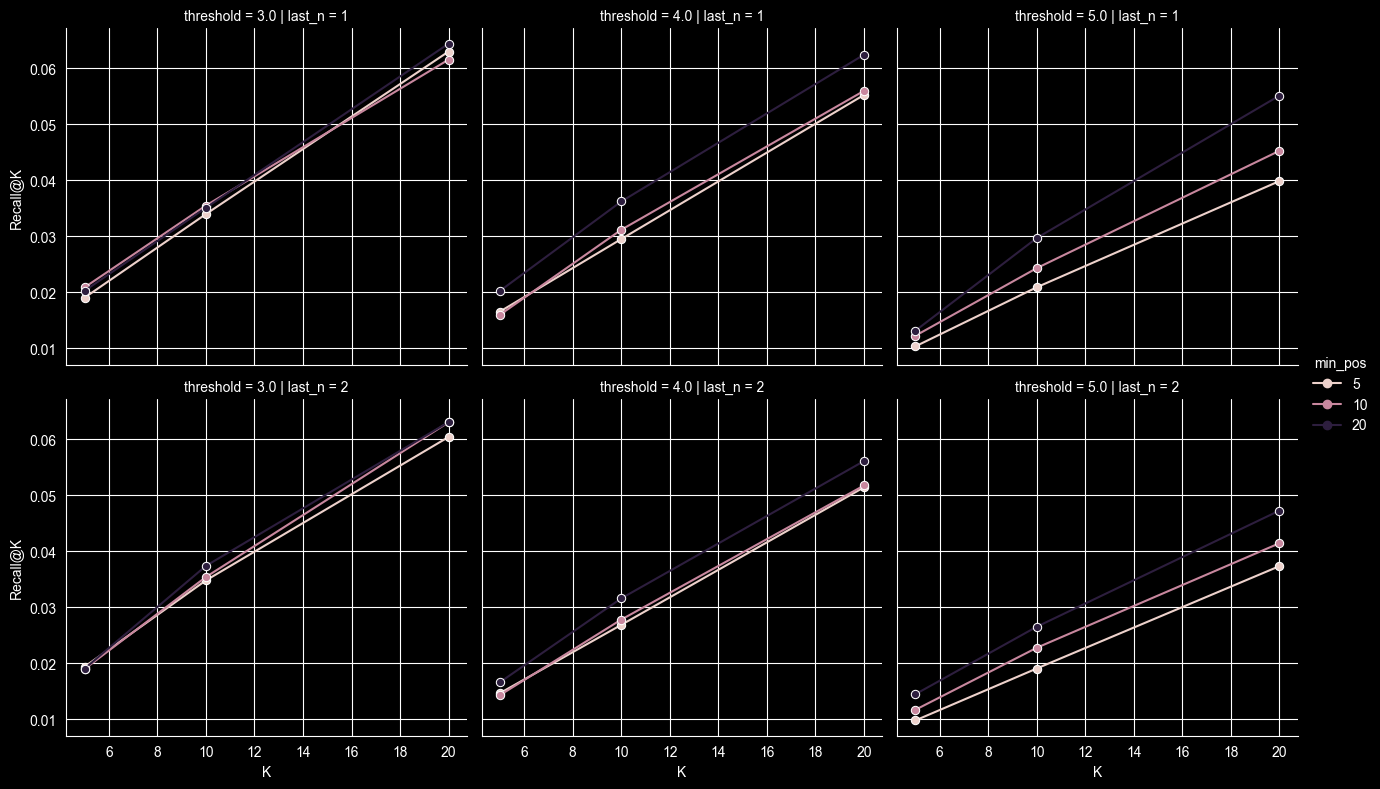

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(
    data=results_df,
    x="k",
    y="recall",
    hue="min_pos",
    col="threshold",
    row="last_n",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("K", "Recall@K")
g.set_titles("threshold = {col_name} | last_n = {row_name}")

plt.show()

- Recall@K монотонно возрастает с увеличением K во всех конфигурациях
- Увеличение min_pos с 5 до 10 приводит к росту Recall (примерно на 5–10%), однако прирост носит умеренный характер
- Разница между last_n = 1 и last_n = 2 для Recall несущественна, что объясняется нормировкой метрики на число релевантных объектов.

Наилучшие значения Recall достигаются при threshold = 3.0, что свидетельствует о важности плотности графа для DeepWalk.

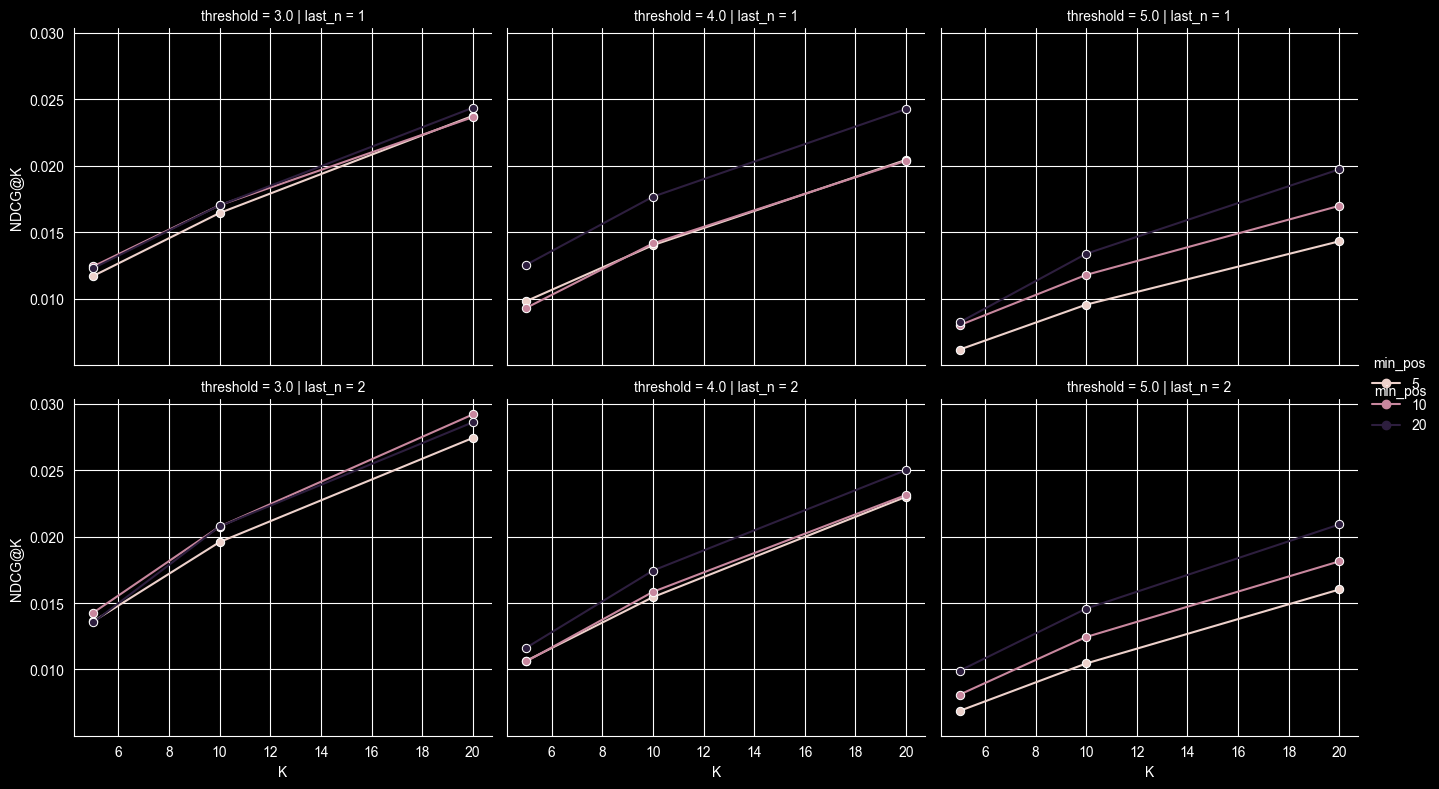

In [37]:
g = sns.relplot(
    data=results_df,
    x="k",
    y="ndcg",
    hue="min_pos",
    col="threshold",
    row="last_n",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("K", "NDCG@K")
g.set_titles("threshold = {col_name} | last_n = {row_name}")
g.add_legend(title="min_pos")

plt.show()

- NDCG@K монотонно возрастает с увеличением K во всех конфигурациях
- Увеличение min_pos с 5 до 10 приводит к стабильному росту NDCG
- При threshold = 5.0 значения NDCG существенно ниже, чем при threshold = 3.0, что подтверждает негативное влияние чрезмерной разреженности графа на качество ранжирования.
- Разница между last_n = 1 и last_n = 2 для NDCG умеренная, но при last_n = 2 наблюдается более стабильный рост на больших K, что связано с наличием двух релевантных объектов в тесте.

DeepWalk демонстрирует умеренное улучшение качества ранжирования при увеличении объёма пользовательской истории (min_pos), однако прирост носит постепенный характер. Наилучшие значения NDCG достигаются при более низком пороге позитивного сигнала (threshold = 3.0), что указывает на критическую роль плотности графа

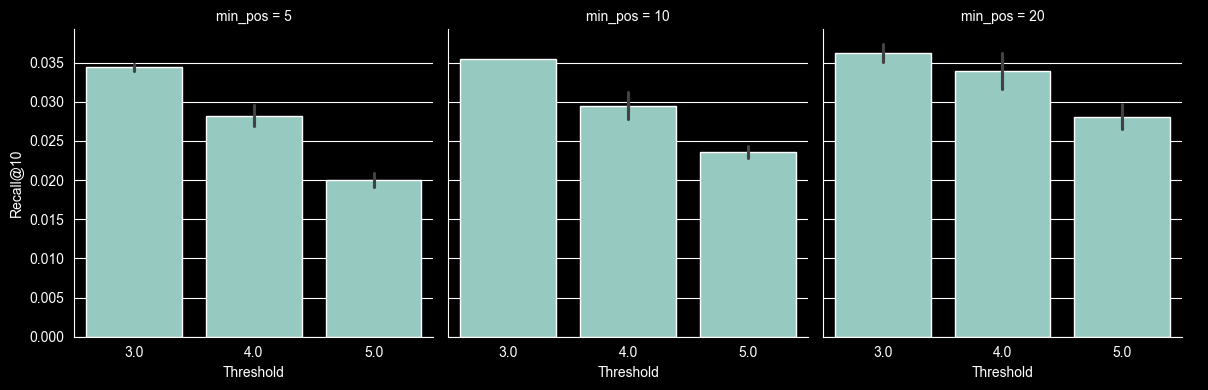

In [38]:
df_k10 = results_df[results_df["k"] == 10]

g = sns.catplot(
    data=df_k10,
    x="threshold",
    y="recall",
    col="min_pos",
    kind="bar",
    height=4,
    aspect=1
)

g.set_axis_labels("Threshold", "Recall@10")
g.set_titles("min_pos = {col_name}")

plt.show()

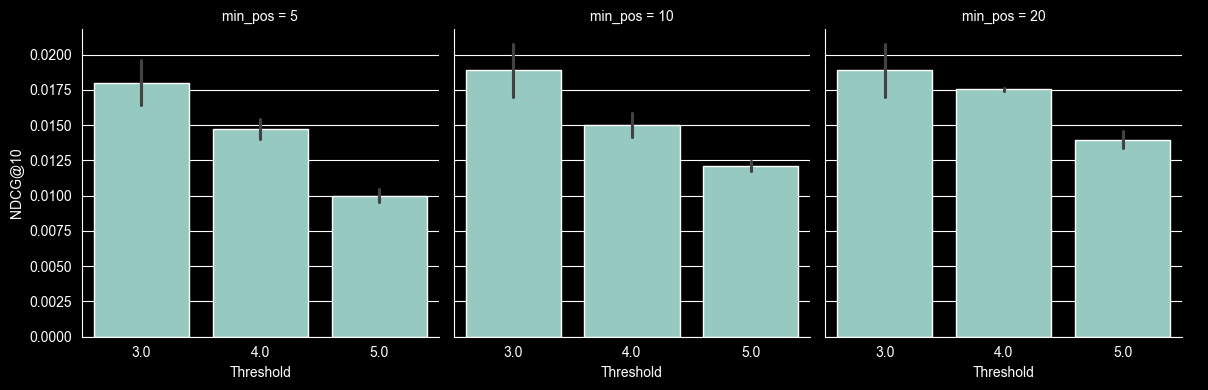

In [39]:
df_k10 = results_df[results_df["k"] == 10]

g = sns.catplot(
    data=df_k10,
    x="threshold",
    y="ndcg",
    col="min_pos",
    kind="bar",
    height=4,
    aspect=1
)

g.set_axis_labels("Threshold", "NDCG@10")
g.set_titles("min_pos = {col_name}")

plt.show()

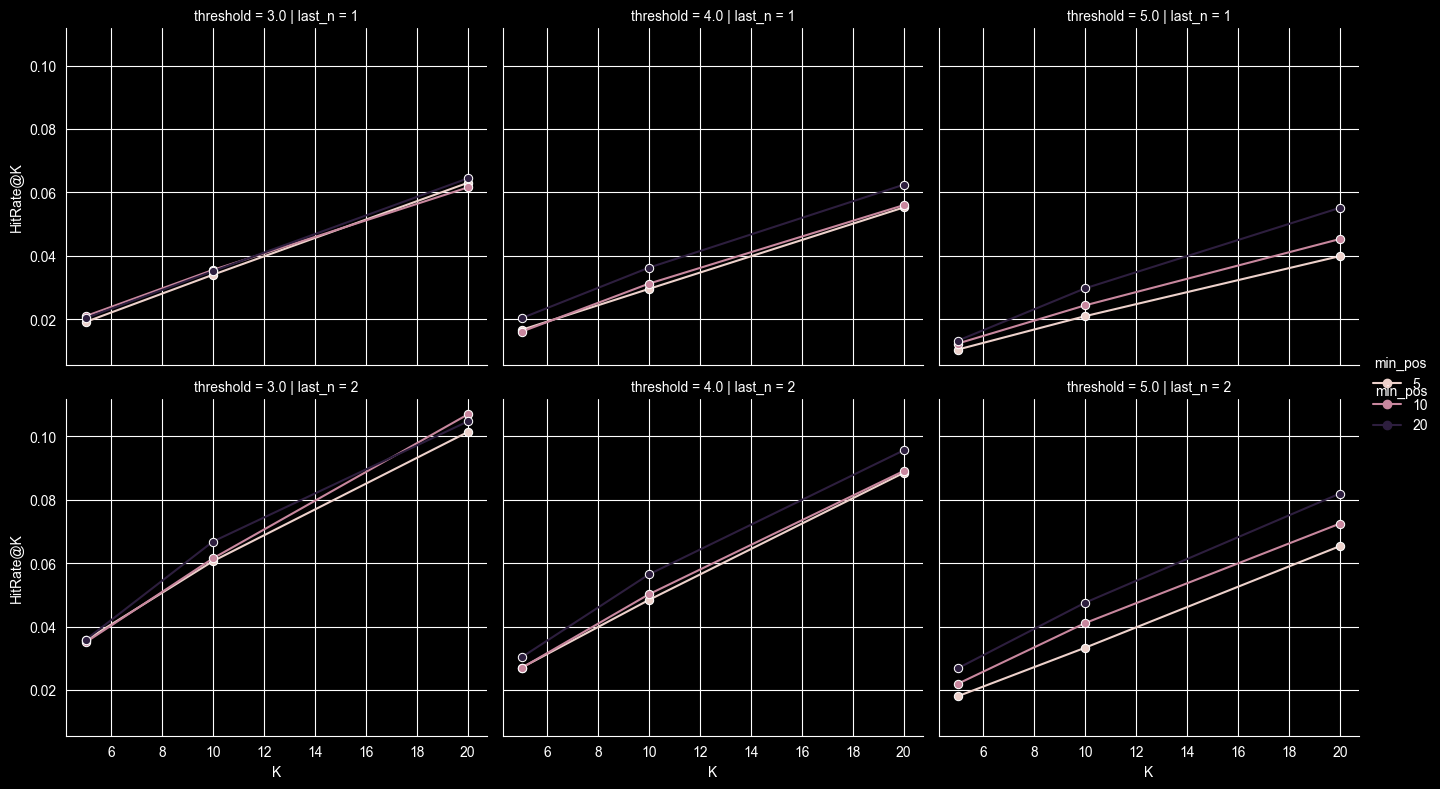

In [40]:
g = sns.relplot(
    data=results_df,
    x="k",
    y="hitrate",
    hue="min_pos",
    col="threshold",
    row="last_n",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("K", "HitRate@K")
g.set_titles("threshold = {col_name} | last_n = {row_name}")
g.add_legend(title="min_pos")

plt.show()

- HitRate@K монотонно возрастает с увеличением K во всех конфигурациях
- При last_n = 2 значения HitRate существенно выше, чем при last_n = 1
- Увеличение min_pos приводит к росту HitRate
- При threshold = 5.0 значения HitRate заметно ниже, чем при threshold = 3.0 и 4.0, что подтверждает негативное влияние избыточной фильтрации и разреженности графа.

HitRate демонстрирует ту же общую тенденцию, что и Recall: наилучшие результаты достигаются при более плотном графе (threshold = 3.0) и большем количестве пользовательских взаимодействий (min_pos = 20). Существенный рост HitRate при last_n = 2 объясняется увеличением числа релевантных объектов в тесте, а не фундаментальным улучшением качества ранжирования.

## Вывод

DeepWalk демонстрирует устойчивую зависимость качества рекомендаций от плотности графа и объёма пользовательской истории. Однако даже при оптимальных параметрах модель достигает умеренных значений метрик (Recall ≈ 6% при K=20), что указывает на структурные ограничения метода.

Модель эффективно использует топологическую информацию, но не способна концентрировать релевантные объекты в верхней части списка без дополнительных механизмов (например, матричной факторизации, контентных признаков или графовых нейронных сетей).